In [11]:
import pandas as pd

archivo = "/content/Datos_Trabajo_de_grado.xlsx"

df = pd.read_excel(archivo)
print(df.head())


  Semestre                        Nombre Tipo doc  #documento Resultado Final  \
0   2025-1     Sebastian Builes Restrepo       CC  1000660285          Negada   
1   2025-1  Luis Jerónimo Valencia Mejía       CC  1023524022          Negada   
2   2025-1         Madelyn Ortiz Quiceno       CC  1018224236        Aprobada   
3   2025-1   MARIA CAMILA TORRES PENAGOS       CC  1105360983          Negada   
4   2025-1        juan jose lopez macias       CC  1000762492          Negada   

   % beca talento final aprobada Pregrado final aprobado talento  \
0                            NaN                             NaN   
1                            NaN                             NaN   
2                            0.7          Ingeniería de Procesos   
3                            NaN                             NaN   
4                            NaN                             NaN   

   Confirma #  doc.  Edad al postularse Lugar de nacimiento  ... Carro Marca  \
0        1000660285     

In [12]:
print(f"\nNúmero de filas y columnas: {df.shape}")

print("\nResumen de estructura del dataset:")
df.info()



Número de filas y columnas: (5890, 140)

Resumen de estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5890 entries, 0 to 5889
Columns: 140 entries, Semestre to Observaciones
dtypes: float64(3), int64(3), object(134)
memory usage: 6.3+ MB


In [13]:
# Identificar columnas numéricas y categóricas automáticamente
variables_numericas = df.select_dtypes(include=["number"]).columns.tolist()
variables_categoricas = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variables numéricas:", variables_numericas)
print("\nVariables categóricas:", variables_categoricas)


Variables numéricas: ['#documento', '% beca talento final aprobada', 'Confirma #  doc.', 'Edad al postularse', 'Año graduación', 'Con cuántas personas vives actualmente']

Variables categóricas: ['Semestre', 'Nombre', 'Tipo doc', 'Resultado Final', 'Pregrado final aprobado talento', 'Lugar de nacimiento', 'Nació en el exterior', 'Sexo biológico', 'Estado civil', 'Víctima del conflicto', 'Víctima de desplazamiento', 'Discapacidad física o psicosocial', 'Grupo étnico', 'Aspirante tiene hijos', '¿Marcardor social?', '¿Alguna otra condición?', 'Barrio', 'Dirección actual', 'Teléfono', 'Celular', 'Correo ', 'Dpto de Residencia', 'Mpio de residencia', 'Puntaje ICFES', 'Año ICFES', 'N° registro ICFES', 'Nombre colegio', 'Tipo colegio', 'Dpto IE', 'Depto IE Otro', 'Mpio IE', 'Act. Artísticas', 'Tiempo', 'Act. deportivas', 'Tiempo.1', 'Act. liderazgo', 'Tiempo.2', ' Trabajo social o comunitario ', 'Tiempo.3', 'Otras actividades', 'Tiempo.4', 'Física 10°', 'Física 11°', 'Química 10°', 'Química 1

In [14]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

nulos_filtrados = nulos[nulos > 0].sort_values(ascending=False)
porcentaje_filtrado = porcentaje_nulos[nulos > 0].sort_values(ascending=False)

print("\nValores nulos por columna:")
for col in nulos_filtrados.index:
    print(f"{col}: {nulos_filtrados[col]} nulos ({porcentaje_filtrado[col]:.2f}%)")



Valores nulos por columna:
Depto IE Otro: 5871 nulos (99.68%)
Nació en el exterior: 5720 nulos (97.11%)
Fam5 Inst/Empresa: 5604 nulos (95.14%)
Otro Modelo: 5590 nulos (94.91%)
Fam5 Ingresos: 5576 nulos (94.67%)
Suficiencia en el idioma inglés: 5558 nulos (94.36%)
Fam5 Cargo/Actividad: 5533 nulos (93.94%)
Fam4 Institución/Empresa: 5504 nulos (93.45%)
Fam5 Parentesc: 5504 nulos (93.45%)
Fam5 Edad: 5498 nulos (93.34%)
Fam4 Ingresos: 5460 nulos (92.70%)
Fam4 Cargo/Actividad: 5403 nulos (91.73%)
Camión Modelo: 5403 nulos (91.73%)
Forma de pago: 5385 nulos (91.43%)
Camión Valor Comercial: 5379 nulos (91.32%)
Otro Valor Comercial: 5345 nulos (90.75%)
Fam4 Parentesco: 5323 nulos (90.37%)
Fam4 Edad: 5319 nulos (90.31%)
Fam5 Nombres: 5309 nulos (90.14%)
Tiempo.4: 5291 nulos (89.83%)
Fam3 Institución/empresa: 5251 nulos (89.15%)
Valor mensual de tus ingresos: 5174 nulos (87.84%)
Actividad por la cual recibes ingresos: 5174 nulos (87.84%)
Camión Marca: 5169 nulos (87.76%)
Fam3 Ingresos: 5169 nulo

<Axes: >

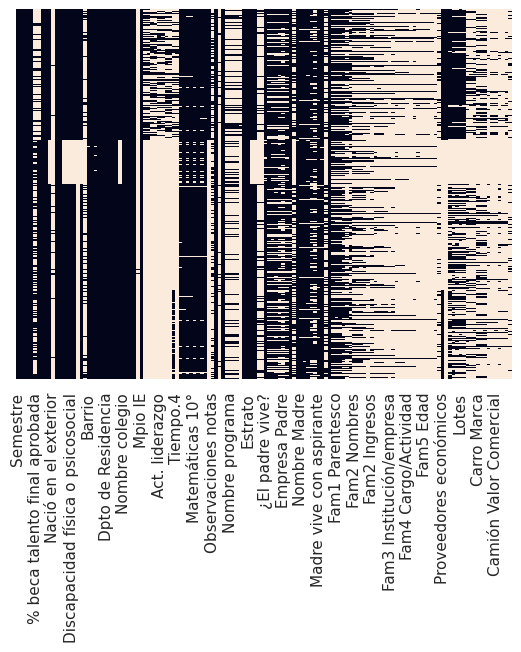

In [18]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)


In [19]:
agrupado = df.groupby("Semestre").agg({
    "Resultado Final": lambda x: x.value_counts().to_dict(),
    "% beca talento final aprobada": lambda x: x.value_counts().to_dict(),
    "¿Marcardor social?": lambda x: x.value_counts().to_dict(),
    "Dpto de Residencia": lambda x: x.value_counts().to_dict(),
    "Puntaje ICFES": "count",
    "Año ICFES": "count",
    "Estrato": lambda x: x.value_counts().to_dict()
})

print(agrupado)


                            Resultado Final  \
Semestre                                      
2023-2     {'Aprobada': 400, 'Negada': 303}   
2024-1    {'Negada': 1181, 'Aprobada': 509}   
2024-2     {'Negada': 808, 'Aprobada': 612}   
2025-1    {'Negada': 1487, 'Aprobada': 590}   

                              % beca talento final aprobada  \
Semestre                                                      
2023-2    {0.4: 117, 0.5: 86, 0.7: 70, 1.0: 49, 0.6: 42,...   
2024-1    {0.4: 226, 0.5: 81, 0.7: 58, 0.6: 58, 0.8: 39,...   
2024-2    {0.4: 280, 0.5: 161, 0.6: 60, 0.7: 47, 0.8: 35...   
2025-1    {0.4: 271, 0.5: 93, 0.6: 74, 0.7: 49, 0.8: 38,...   

               ¿Marcardor social?  \
Semestre                            
2023-2                         {}   
2024-1    {'NO': 1324, 'SI': 366}   
2024-2    {'NO': 1135, 'SI': 285}   
2025-1    {'NO': 1723, 'SI': 354}   

                                         Dpto de Residencia  Puntaje ICFES  \
Semestre                             

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

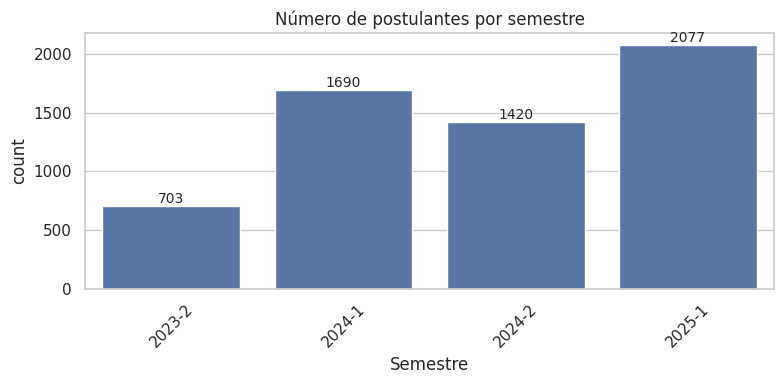

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

orden_semestres = ["2023-2", "2024-1", "2024-2", "2025-1"]
ax = sns.countplot(x="Semestre", data=df, order=orden_semestres)

plt.title("Número de postulantes por semestre")
plt.xticks(rotation=45)
plt.tight_layout()


for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{int(altura)}',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=10)

plt.show()


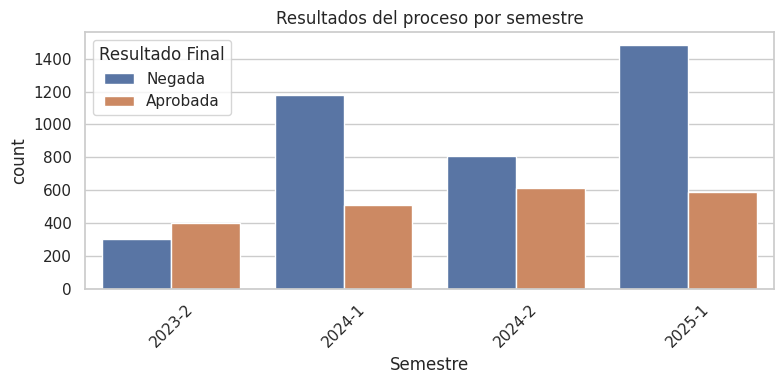

In [20]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x="Semestre", hue="Resultado Final", data=df, order=orden_semestres)
plt.title("Resultados del proceso por semestre")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


/tmp/ipython-input-698479867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


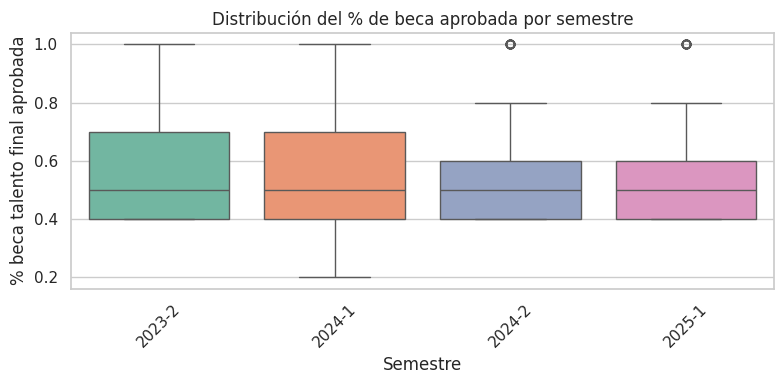

In [21]:
plt.figure(figsize=(8, 4))

palette_colores = sns.color_palette("Set2", n_colors=len(orden_semestres))

sns.boxplot(
    x="Semestre",
    y="% beca talento final aprobada",
    data=df,
    order=orden_semestres,
    palette=palette_colores
)

plt.title("Distribución del % de beca aprobada por semestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


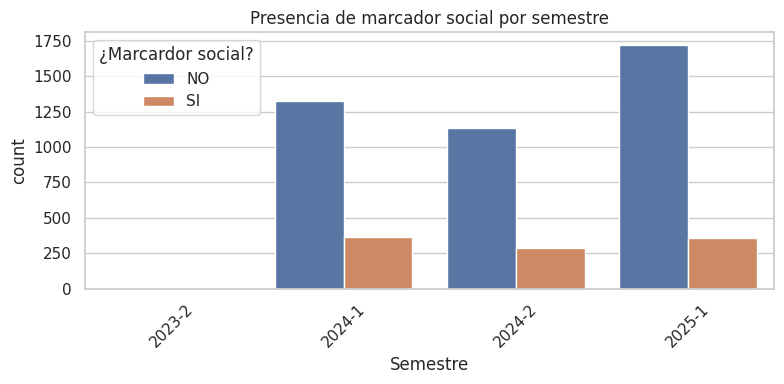

In [22]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x="Semestre", hue="¿Marcardor social?", data=df, order=orden_semestres)
plt.title("Presencia de marcador social por semestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


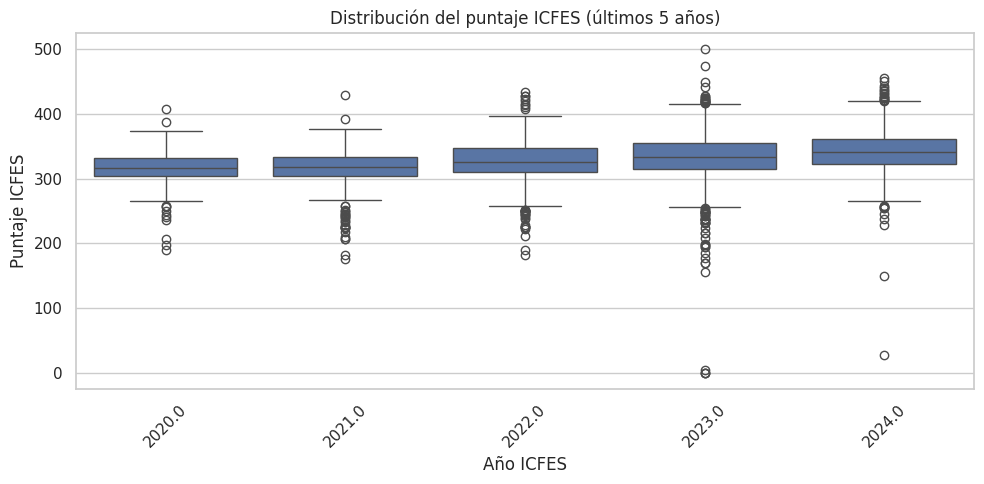

In [23]:
df["Puntaje ICFES"] = pd.to_numeric(df["Puntaje ICFES"], errors="coerce")
df["Año ICFES"] = pd.to_numeric(df["Año ICFES"], errors="coerce")


df_icfes = df[(df["Puntaje ICFES"].notnull()) & (df["Año ICFES"].notnull())]
df_icfes = df[(df["Puntaje ICFES"].notnull()) & (df["Año ICFES"].notnull())]

años_deseados = [2020, 2021, 2022, 2023, 2024]
df_filtrado = df[df["Año ICFES"].isin(años_deseados) & df["Puntaje ICFES"].notnull()]

plt.figure(figsize=(10, 5))
sns.boxplot(x="Año ICFES", y="Puntaje ICFES", data=df_filtrado)
plt.title("Distribución del puntaje ICFES (últimos 5 años)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()







In [24]:
df["Total ingresos padres"] = pd.to_numeric(df["Total ingresos padres"], errors="coerce")
df_ingresos = df[df["Total ingresos padres"].notnull()]


/tmp/ipython-input-1109351170.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


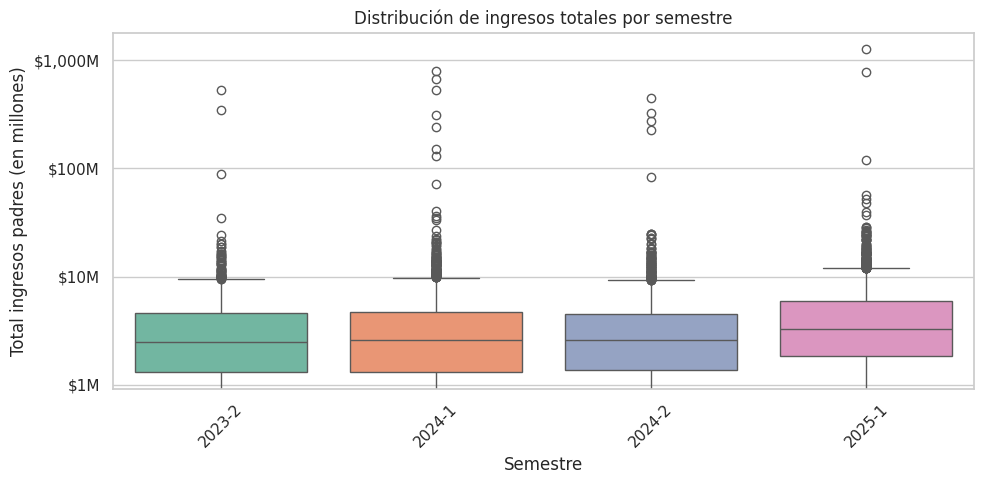

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(10, 5))

# Boxplot con orden y colores personalizados
orden_semestres = ["2023-2", "2024-1", "2024-2", "2025-1"]
palette = sns.color_palette("Set2", len(orden_semestres))

sns.boxplot(
    x="Semestre",
    y="Total ingresos padres",
    data=df_ingresos,
    order=orden_semestres,
    palette=palette,
    ax=ax
)

# Escala logarítmica
ax.set_yscale("log")

# Formateo del eje Y en millones
formatter = ticker.FuncFormatter(lambda x, _: f"${int(x/1e6):,}M")
ax.yaxis.set_major_formatter(formatter)

# Personalización
ax.set_title("Distribución de ingresos totales por semestre")
ax.set_ylabel("Total ingresos padres (en millones)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [26]:
for col in variables_numericas:
    print(f"\n>> {col}")
    print(df.groupby("Resultado Final")[col].mean())




>> #documento
Resultado Final
Aprobada    1.029583e+09
Negada      1.020789e+09
Name: #documento, dtype: float64

>> % beca talento final aprobada
Resultado Final
Aprobada    0.542671
Negada           NaN
Name: % beca talento final aprobada, dtype: float64

>> Confirma #  doc.
Resultado Final
Aprobada    1.027692e+09
Negada      1.022585e+09
Name: Confirma #  doc., dtype: float64

>> Edad al postularse
Resultado Final
Aprobada    18.173214
Negada      19.346114
Name: Edad al postularse, dtype: float64

>> Año graduación
Resultado Final
Aprobada    2021.496921
Negada      2019.542472
Name: Año graduación, dtype: float64

>> Con cuántas personas vives actualmente
Resultado Final
Aprobada    2.870836
Negada      3.025892
Name: Con cuántas personas vives actualmente, dtype: float64


In [27]:
import numpy as np

def calcular_eta_squared(df, num_col, cat_col):
    grupos = df.groupby(cat_col)[num_col]
    medias_grupo = grupos.mean()
    media_total = df[num_col].mean()
    ss_between = sum(grupos.count() * (medias_grupo - media_total) ** 2)
    ss_total = sum((df[num_col] - media_total) ** 2)
    return ss_between / ss_total if ss_total > 0 else np.nan

# Aplicar eta squared para cada numérica
print("\nCorrelación eta² de variables numéricas con Resultado Final:")
for col in variables_numericas:
    eta = calcular_eta_squared(df, col, "Resultado Final")
    if not np.isnan(eta):
        print(f"{col}: η² = {eta:.3f}")



Correlación eta² de variables numéricas con Resultado Final:
#documento: η² = 0.001
Confirma #  doc.: η² = 0.000
Edad al postularse: η² = 0.025
Año graduación: η² = 0.000


In [28]:
# Variables numéricas útiles
variables_relevantes = [
    "% beca talento final aprobada",
    "Edad al postularse",
    "Puntaje ICFES",
    "Año ICFES",
    "Año graduación",
    "Total ingresos padres",
    "Con cuántas personas vives actualmente"
]


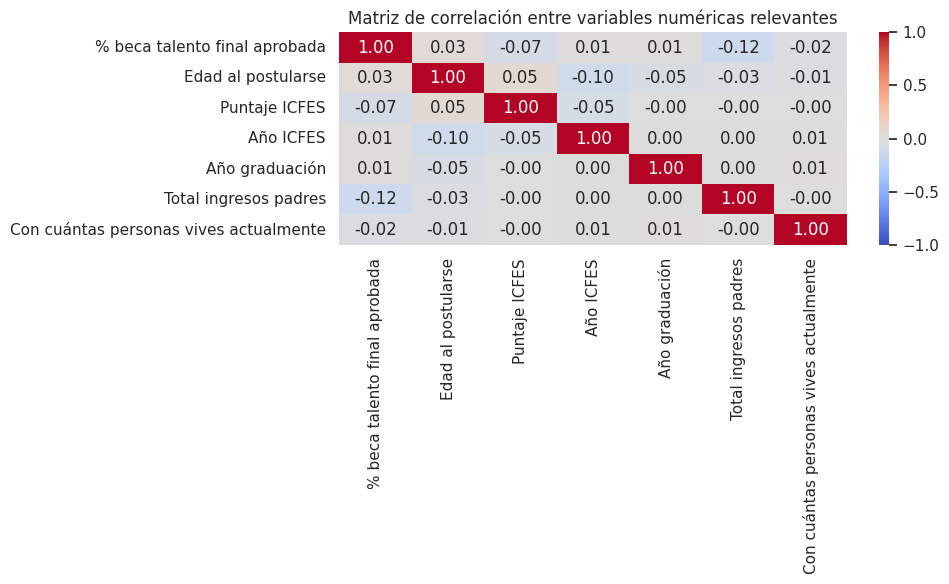

In [29]:
# Correlación solo con variables relevantes
corr = df[variables_relevantes].corr()

# Visualización
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables numéricas relevantes")
plt.tight_layout()
plt.show()


In [30]:
df.groupby("Resultado Final")[variables_numericas].describe()


#documento                                        \
                     count          mean           std       min   
Resultado Final                                                    
Aprobada            2111.0  1.029583e+09  1.117229e+08  536504.0   
Negada              3779.0  1.020789e+09  1.718134e+08  389969.0   

                                                                         \
                          25%           50%           75%           max   
Resultado Final                                                           
Aprobada         1.018239e+09  1.031941e+09  1.040875e+09  2.000015e+09   
Negada           1.018228e+09  1.032012e+09  1.040874e+09  3.182842e+09   

                % beca talento final aprobada            ... Año graduación  \
                                        count      mean  ...            75%   
Resultado Final                                          ...                  
Aprobada                               2074.0  0.542671  ...         2023.0   
Negada                                    0.0       NaN  ...         2024.0   

                        Con cuántas personas vives actualmente            \
                    max                                  count      mean   
Resultado Final                                                            
Aprobada         2024.0                                 1711.0  2.870836   
Negada           2024.0                                 3476.0  3.025892   

                                                      
                      std  min  25%  50%  75%    max  
Resultado Final                                       
Aprobada         1.334310  0.0  2.0  3.0  4.0   10.0  
Negada           5.763084  0.0  2.0  3.0  4.0  333.0  

[2 rows x 48 columns]

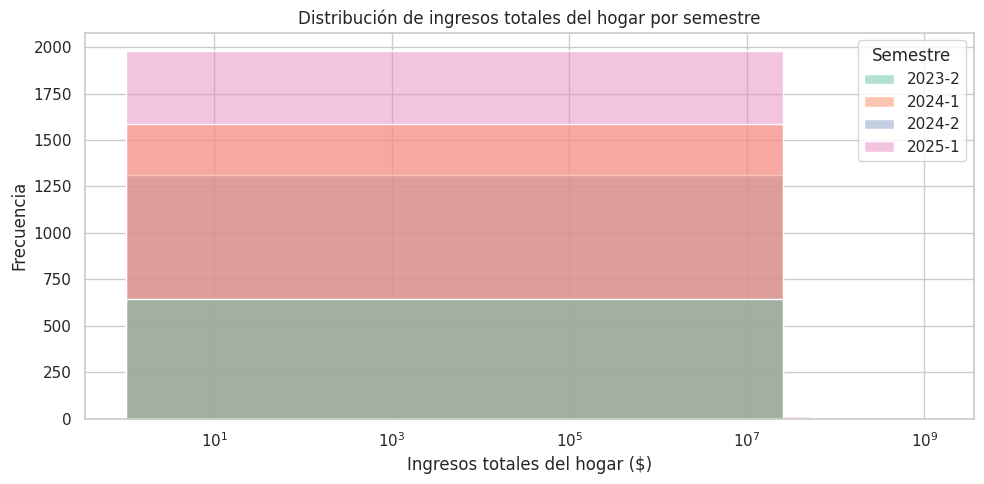

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

df["Total ingresos padres"] = pd.to_numeric(df["Total ingresos padres"], errors="coerce")
df_ingresos = df[df["Total ingresos padres"] > 0]

orden_semestres = ["2023-2", "2024-1", "2024-2", "2025-1"]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_ingresos,
    x="Total ingresos padres",
    hue="Semestre",
    multiple="layer",
    bins=50,
    palette="Set2",
    hue_order=orden_semestres
)

plt.title("Distribución de ingresos totales del hogar por semestre")
plt.xlabel("Ingresos totales del hogar ($)")
plt.ylabel("Frecuencia")
plt.xscale("log")
plt.tight_layout()
plt.show()


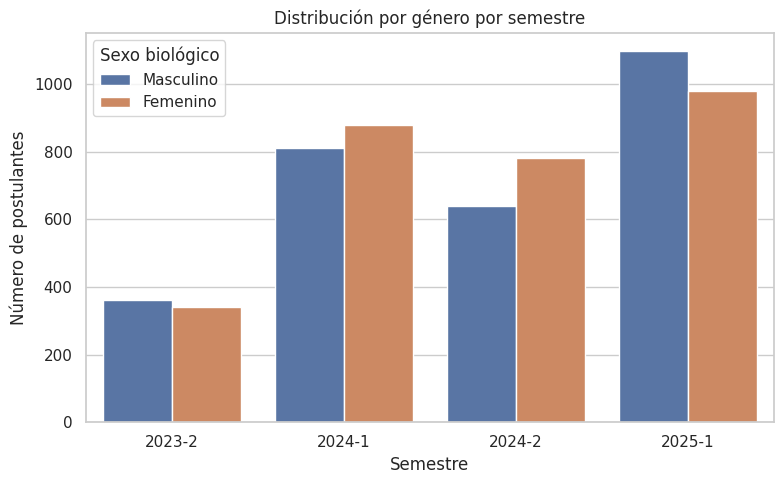

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Semestre", hue="Sexo biológico", order=sorted(df["Semestre"].unique()))
plt.title("Distribución por género por semestre")
plt.ylabel("Número de postulantes")
plt.xlabel("Semestre")
plt.legend(title="Sexo biológico")
plt.tight_layout()
plt.show()


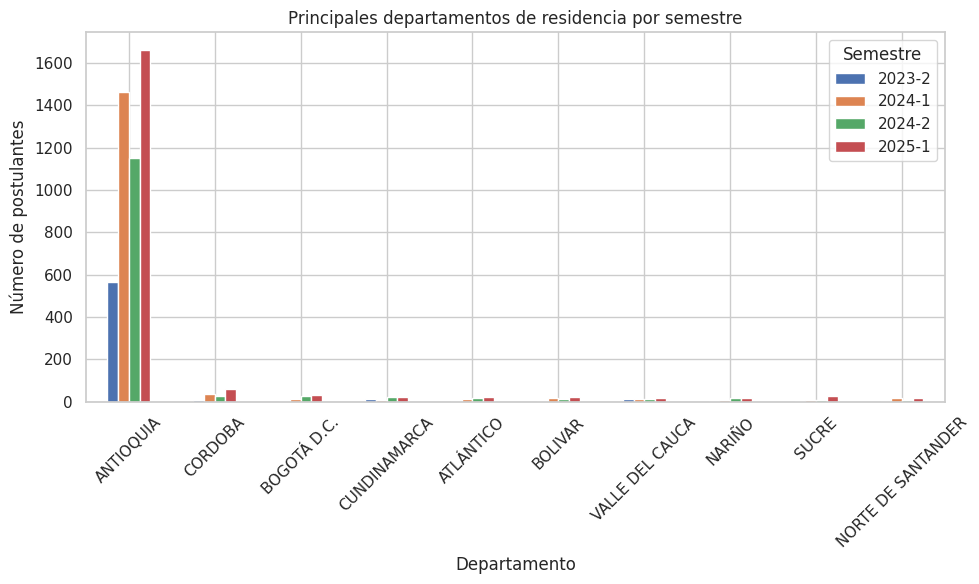

In [33]:
# Estandarizar el texto de la columna "Dpto de Residencia"
df["Dpto de Residencia"] = df["Dpto de Residencia"].str.upper().str.strip()

# Luego puedes volver a graficar
deptos = df.groupby("Dpto de Residencia")["Semestre"].value_counts().unstack().fillna(0)
top_deptos = deptos.sum(axis=1).sort_values(ascending=False).head(10).index
deptos.loc[top_deptos].plot(kind="bar", figsize=(10, 6))

plt.title("Principales departamentos de residencia por semestre")
plt.ylabel("Número de postulantes")
plt.xlabel("Departamento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


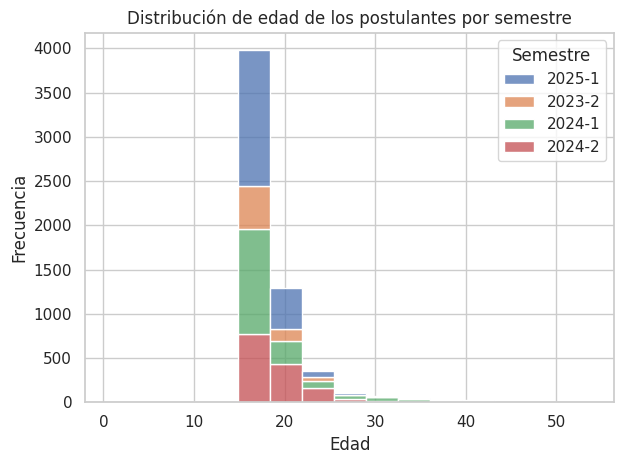

In [34]:
sns.histplot(data=df[df["Edad al postularse"] > 0], x="Edad al postularse", hue="Semestre", bins=15, multiple="stack")
plt.title("Distribución de edad de los postulantes por semestre")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
